In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
df_videojuegos = pd.read_csv("09. videojuegos (2).csv")
df_videojuegos.head()

,Nombre,Plataforma,Anio_Lanzamiento,Genero,Ventas_NA,Ventas_EU,Ventas_JP,Critica_Puntaje
0,Juego_0,Xbox,2011,Aventura,13.516229,8.243746,1.860090,NaN
1,Juego_1,Nintendo,2019,Acción,9.533212,3.665887,3.882065,97.0
2,Juego_2,PC,2021,Aventura,5.151544,1.357899,1.704018,67.0
3,Juego_3,Xbox,2011,Estrategia,5.303223,5.270208,4.653787,75.0
4,Juego_4,Xbox,2019,Estrategia,10.916740,7.722936,4.292064,65.0


In [20]:
df_videojuegos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Nombre            100 non-null    object 
 1   Plataforma        100 non-null    object 
 2   Anio_Lanzamiento  100 non-null    int64  
 3   Genero            100 non-null    object 
 4   Ventas_NA         100 non-null    float64
 5   Ventas_EU         100 non-null    float64
 6   Ventas_JP         100 non-null    float64
 7   Critica_Puntaje   90 non-null     float64
dtypes: float64(4), int64(1), object(3)
memory usage: 6.4+ KB


In [21]:
df_videojuegos.isnull().sum()

,0
Nombre,0
Plataforma,0
Anio_Lanzamiento,0
Genero,0
Ventas_NA,0
Ventas_EU,0
Ventas_JP,0
Critica_Puntaje,10


In [22]:
df_videojuegos.shape

(100, 8)

In [23]:
df_videojuegos.describe()

,Anio_Lanzamiento,Ventas_NA,Ventas_EU,Ventas_JP,Critica_Puntaje
count,100.000000,100.000000,100.000000,100.000000,90.000000
mean,2016.490000,8.108120,4.795395,2.645642,68.700000
std,3.783257,4.359312,2.901882,1.568193,17.873117
min,2010.000000,0.175418,0.242496,0.054188,40.000000
25%,2013.000000,4.484096,1.992912,1.456681,52.000000
50%,2017.000000,8.706121,5.024023,2.758458,68.500000
75%,2020.000000,11.946344,7.093285,3.984421,85.750000
max,2022.000000,14.851802,9.906001,4.964824,99.000000


In [24]:
correlacion = df_videojuegos.corr(numeric_only=True)
correlacion

,Anio_Lanzamiento,Ventas_NA,Ventas_EU,Ventas_JP,Critica_Puntaje
Anio_Lanzamiento,1.000000,-0.102427,-0.088245,0.013469,-0.083983
Ventas_NA,-0.102427,1.000000,-0.204332,-0.023772,0.040401
Ventas_EU,-0.088245,-0.204332,1.000000,0.180201,-0.121058
Ventas_JP,0.013469,-0.023772,0.180201,1.000000,-0.071047
Critica_Puntaje,-0.083983,0.040401,-0.121058,-0.071047,1.000000


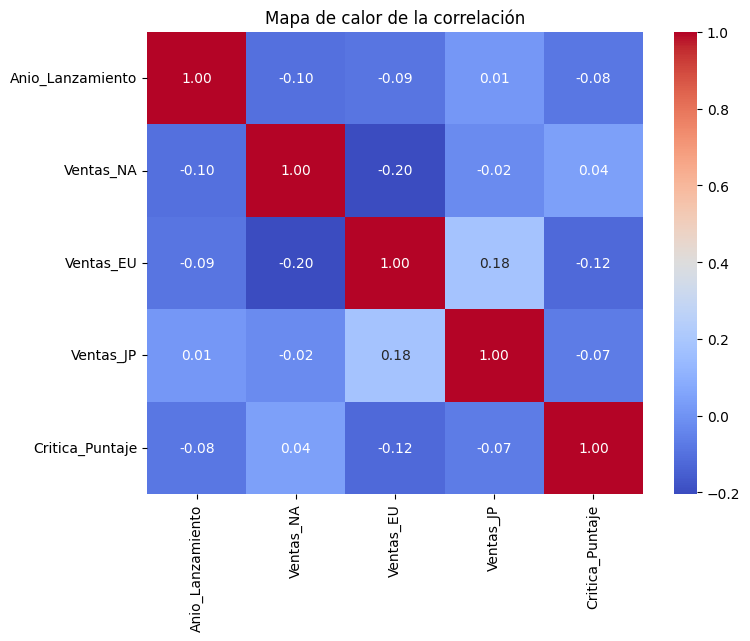

In [25]:
plt.figure(figsize=(8,6))
sns.heatmap(correlacion, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Mapa de calor de la correlación")
plt.show()

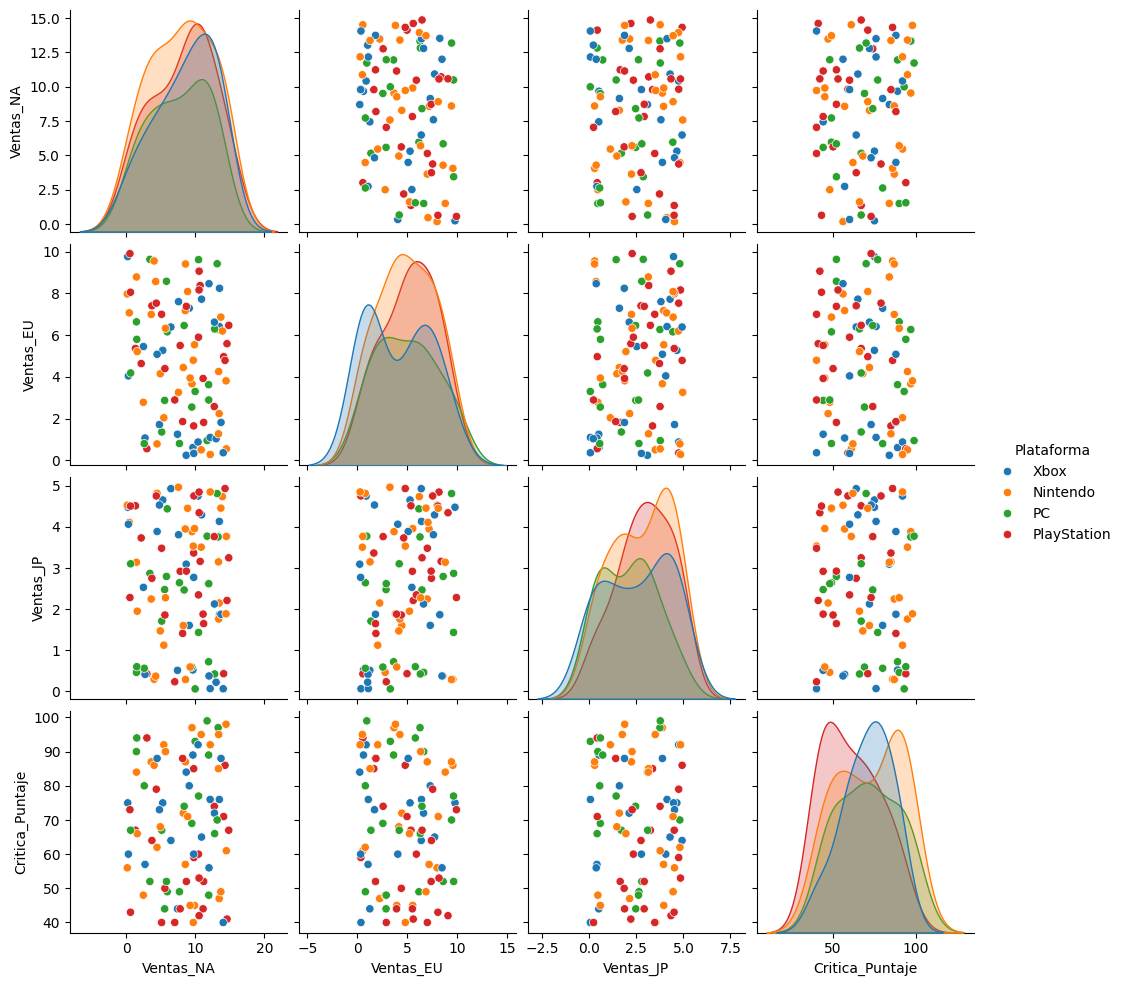

In [26]:
sns.pairplot(
    df_videojuegos,
    vars=["Ventas_NA", "Ventas_EU", "Ventas_JP", "Critica_Puntaje"],
    hue="Plataforma"
)

plt.show()

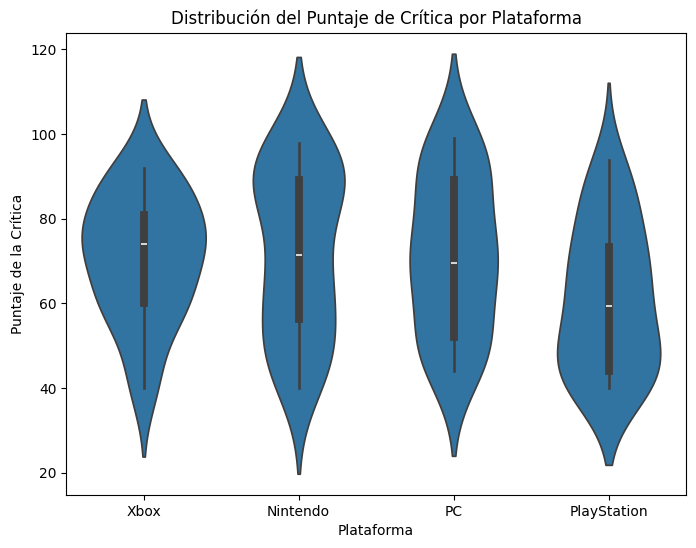

In [27]:
plt.figure(figsize=(8,6))

sns.violinplot(
    data=df_videojuegos,
    x="Plataforma",
    y="Critica_Puntaje"
)

plt.title("Distribución del Puntaje de Crítica por Plataforma")
plt.xlabel("Plataforma")
plt.ylabel("Puntaje de la Crítica")

plt.show()

In [28]:
df_videojuegos["Ventas_Globales"] = (
    df_videojuegos["Ventas_NA"] +
    df_videojuegos["Ventas_EU"] +
    df_videojuegos["Ventas_JP"]
)

df_videojuegos.head()

,Nombre,Plataforma,Anio_Lanzamiento,Genero,Ventas_NA,Ventas_EU,Ventas_JP,Critica_Puntaje,Ventas_Globales
0,Juego_0,Xbox,2011,Aventura,13.516229,8.243746,1.860090,NaN,23.620065
1,Juego_1,Nintendo,2019,Acción,9.533212,3.665887,3.882065,97.0,17.081164
2,Juego_2,PC,2021,Aventura,5.151544,1.357899,1.704018,67.0,8.213461
3,Juego_3,Xbox,2011,Estrategia,5.303223,5.270208,4.653787,75.0,15.227218
4,Juego_4,Xbox,2019,Estrategia,10.916740,7.722936,4.292064,65.0,22.931740


In [29]:
ventas_genero = df_videojuegos.groupby("Genero")["Ventas_Globales"].mean()

ventas_genero

,Ventas_Globales
Genero,
Acción,15.884657
Aventura,12.376321
Deportes,14.800334
Estrategia,16.835730
RPG,15.784117


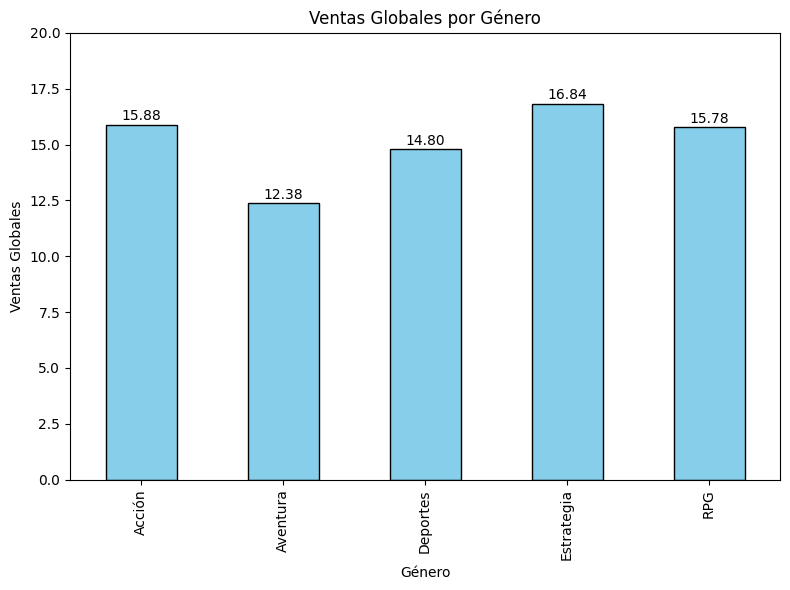

In [30]:
plt.figure(figsize=(8,6))

ax = ventas_genero.plot(
    kind="bar",
    color="skyblue",
    edgecolor="black"
)

plt.title("Ventas Globales por Género")
plt.xlabel("Género")
plt.ylabel("Ventas Globales")

plt.ylim(0, 20)

for i, valor in enumerate(ventas_genero):
    plt.text(i, valor + 0.2, f"{valor:.2f}", ha="center")

plt.tight_layout()

plt.savefig("ventas_por_genero_personalizado.png", dpi=300)

plt.show()